In [1]:

# Create the students.csv file with the provided dataset


# Writing the dataset to a csv file
with open("students.csv", "w", encoding="utf-8") as f:
    f.write("name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed\n")
    f.write("Alice,88,92,76,80,95,92,4.5,1\n")
    f.write("Bob,42,55,48,50,60,65,1.2,0\n")
    f.write("Charlie,75,70,80,68,88,85,3.0,1\n")
    f.write("Diana,95,98,91,89,97,98,6.0,1\n")
    f.write("Eve,38,42,50,45,55,58,0.8,0\n")
    f.write("Frank,60,65,72,58,70,78,2.5,1\n")
    f.write("Grace,55,48,44,52,62,60,1.5,0\n")
    f.write("Henry,82,79,85,77,90,88,4.0,1\n")
    f.write("Iris,70,74,68,65,78,80,3.5,1\n")
    f.write("Jack,30,35,40,28,45,50,0.5,0\n")
    f.write("Karen,65,60,70,62,75,72,2.8,1\n")
    f.write("Liam,48,52,44,55,58,62,1.8,0\n")
    f.write("Mia,91,94,88,92,96,95,5.5,1\n")
    f.write("Noah,58,62,55,60,68,70,2.0,0\n")
    f.write("Olivia,78,75,82,70,85,84,3.8,1\n")

print("students.csv created successfully!")

students.csv created successfully!


In [2]:
# ============================================================
# TASK 1 — Data Exploration with Pandas
# ============================================================

# Import pandas library for data manipulation
import pandas as pd

# Load the dataset from the csv file we just created
df = pd.read_csv("students.csv")

# Print the first 5 rows to see what the data looks like
print("--- First 5 Rows ---")
print(df.head())

# Print the shape — how many rows and columns
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")

# Print the data type of each column
print("\n--- Data Types ---")
print(df.dtypes)


# Print summary statistics for all numeric columns
print("\n--- Summary Statistics ---")
print(df.describe())

# Count how many students passed and failed
print("\n--- Pass/Fail Count ---")
print(df['passed'].value_counts())


# Define the subject columns we'll work with
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Compute average scores per subject for passing students
print("\n--- Average Scores for Passing Students ---")
print(df[df['passed'] == 1][subject_cols].mean())

# Compute average scores per subject for failing students
print("\n--- Average Scores for Failing Students ---")
print(df[df['passed'] == 0][subject_cols].mean())

# Find the student with the highest overall average across all 5 subjects
df['temp_avg'] = df[subject_cols].mean(axis=1)
best_student_index = df['temp_avg'].idxmax()
best_student = df.loc[best_student_index]

print(f"\n--- Top Student ---")
print(f"Name: {best_student['name']}, Average Score: {best_student['temp_avg']:.2f}")

--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: 15 rows x 9 columns

--- Data Types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
         

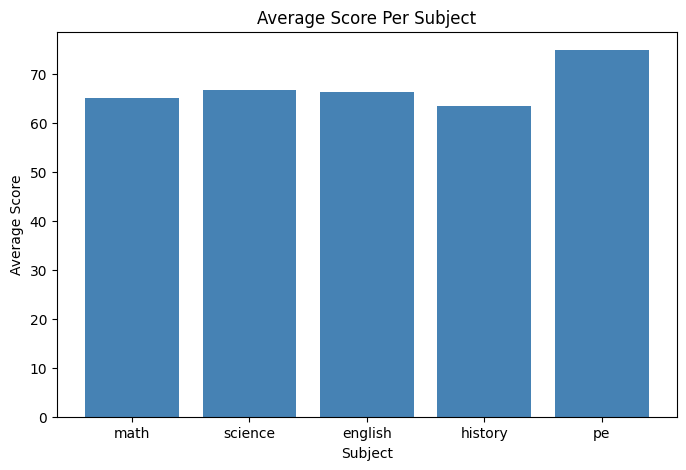

Plot 1 saved!


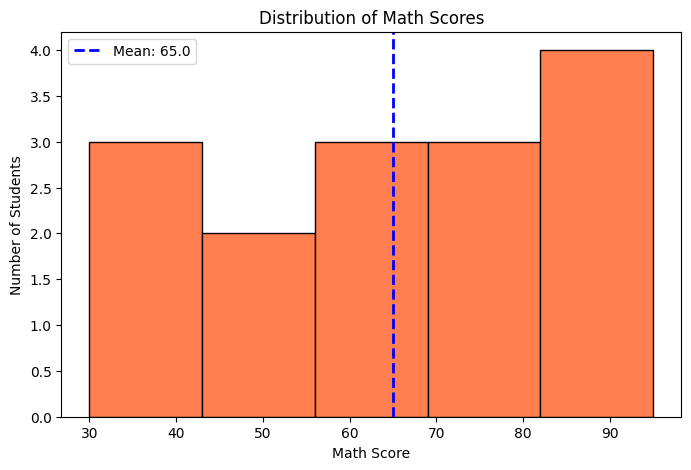

Plot 2 saved!


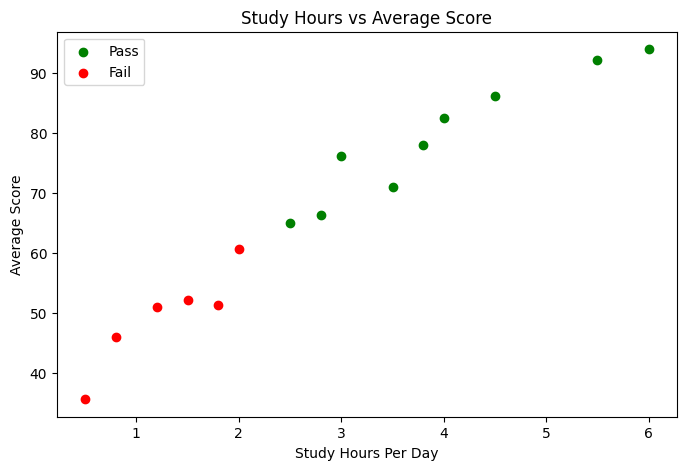

Plot 3 saved!


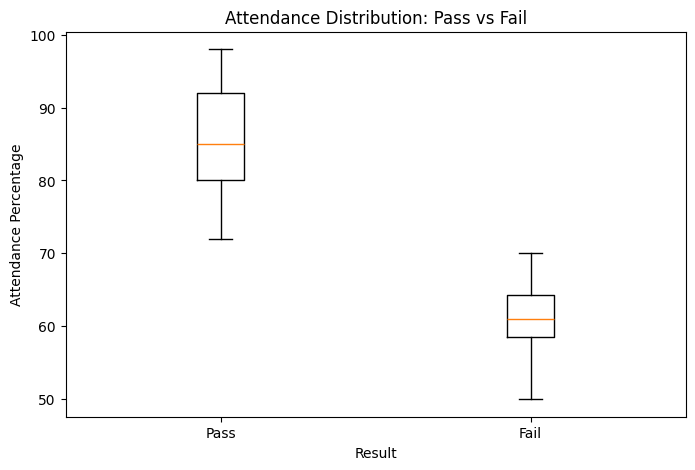

Plot 4 saved!


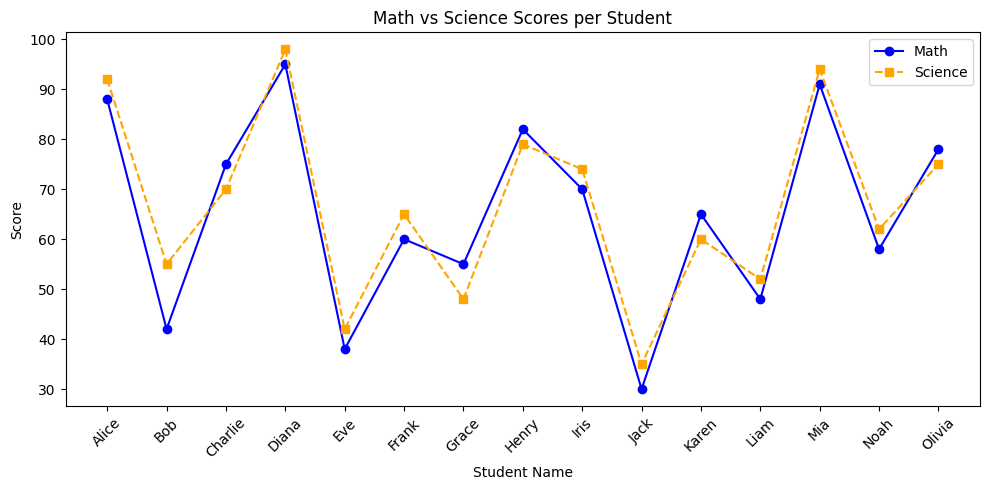

Plot 5 saved!


In [3]:
# TASK 2 — Data Visualization with Matplotlib


# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Add avg_score column to the dataframe
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# ---- Plot 1: Bar Chart — Average score per subject ----

# Calculate average score for each subject
avg_scores = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_cols, avg_scores, color='steelblue')
plt.title("Average Score Per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()
print("Plot 1 saved!")


#-------------------------------------------------------------------------------

# ---- Plot 2: Histogram — Distribution of math scores ----

# Calculate the mean math score for the vertical line
mean_math = df['math'].mean()

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')

# Add a vertical dashed line at the mean
plt.axvline(mean_math, color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {mean_math:.1f}')

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()
print("Plot 2 saved!")


#-------------------------------------------------------------------------------

# ---- Plot 3: Scatter Plot — study hours vs avg score ----

# Separate passing and failing students
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))

# Plot passing students in green and failing in red
plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], color='green', label='Pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], color='red', label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()
print("Plot 3 saved!")

#-------------------------------------------------------------------------------

# ---- Plot 4: Box Plot — attendance_pct for Pass vs Fail ----

# Get attendance data for passing and failing students separately
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_box.png")
plt.show()
print("Plot 4 saved!")


#-------------------------------------------------------------------------------

# ---- Plot 5: Line Plot — math and science scores for every student ----

plt.figure(figsize=(10, 5))

# Plot math scores with circle markers
plt.plot(df['name'], df['math'], marker='o', linestyle='-', color='blue', label='Math')

# Plot science scores with square markers
plt.plot(df['name'], df['science'], marker='s', linestyle='--', color='orange', label='Science')

plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

# Rotate x-axis labels so names don't overlap
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()
print("Plot 5 saved!")

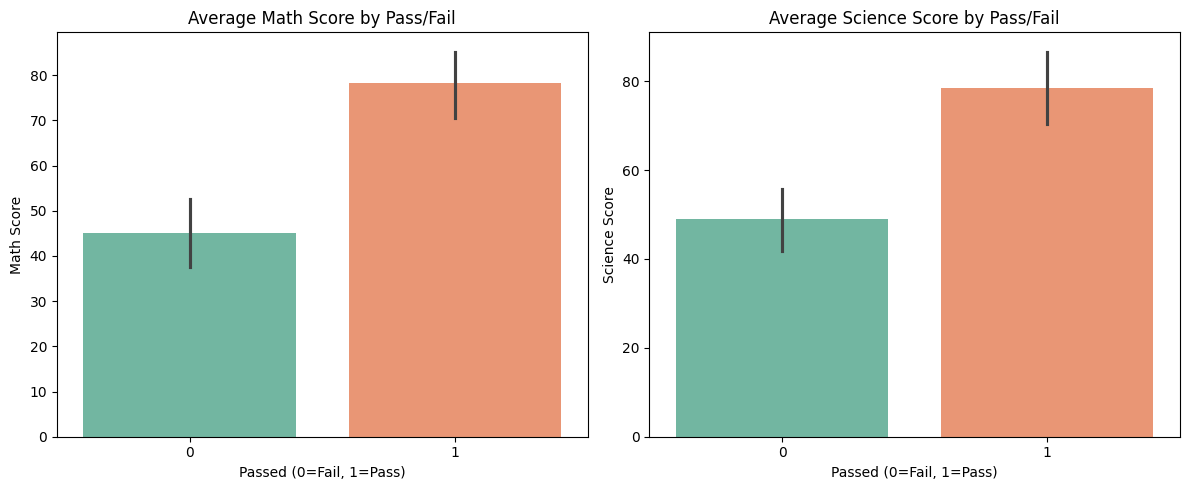

Plot 6 saved!


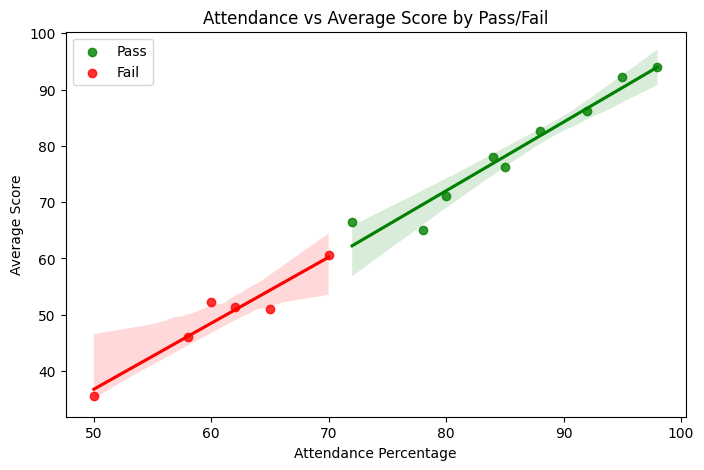

Plot 7 saved!


In [4]:
# TASK 3 — Data Visualization with Seaborn


# Import seaborn library
import seaborn as sns

# ---- Plot 6: Seaborn Bar Plot — avg math and science score by passed ----

# Create a figure with two side by side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot average math score split by passed
sns.barplot(data=df, x='passed', y='math', ax=ax1, hue='passed', legend=False, palette='Set2')
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Plot average science score split by passed
sns.barplot(data=df, x='passed', y='science', ax=ax2, hue='passed', legend=False, palette='Set2')
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()
print("Plot 6 saved!")


# ---- Plot 7: Seaborn Scatter Plot — attendance vs avg_score with regression line ----

plt.figure(figsize=(8, 5))

# Plot regression line and scatter for passing students
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', label='Pass', color='green')

# Plot regression line and scatter for failing students
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', label='Fail', color='red')

plt.title("Attendance vs Average Score by Pass/Fail")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()
print("Plot 7 saved!")

# ---- Seaborn vs Matplotlib comparison ----
# Seaborn made it much easier to create grouped bar plots and add regression lines
# with just one line of code. Matplotlib required more manual steps like separating
# groups and customising colours. Seaborn is better for statistical plots while
# Matplotlib gives more control over every detail.

Data prepared successfully!
Training samples : 12
Testing samples  : 3
Training Accuracy: 100.00%
Test Accuracy: 100.00%

--- Prediction Results ---
Jack       | Actual: Fail  | Predicted: Fail  | ✅ Correct
Liam       | Actual: Fail  | Predicted: Fail  | ✅ Correct
Alice      | Actual: Pass  | Predicted: Pass  | ✅ Correct

--- Feature Coefficients (sorted by importance) ---
english                   : 0.8125
attendance_pct            : 0.5219
study_hours_per_day       : 0.4844
pe                        : 0.4750
math                      : 0.4379
science                   : 0.3230
history                   : 0.2629


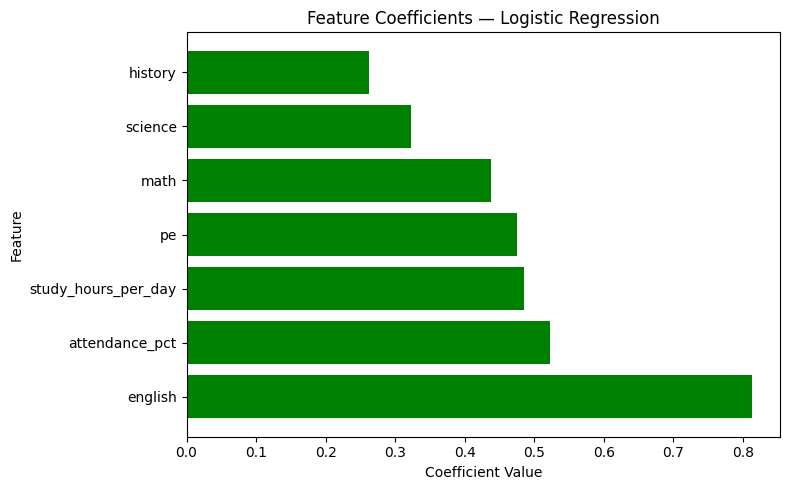

Feature importance plot saved!

--- New Student Prediction ---
Prediction  : Pass
Probability : Fail = 0.09, Pass = 0.91


In [5]:
# TASK 4 — Machine Learning with scikit-learn


# Import the libraries we need for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


#-------------------------------------------------------------------------------


# Step 1 — Prepare Data

# Define the feature columns (everything except name and passed)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

# X = features (input), y = target (output)
X = df[feature_cols]
y = df['passed']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features — fit on training data only, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Data prepared successfully!")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


#-------------------------------------------------------------------------------


# Step 2 — Train a Logistic Regression model

# Create the model
model = LogisticRegression(random_state=42)

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

# Print training accuracy
train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")


#-------------------------------------------------------------------------------

# Step 3 — Evaluate the Model on test data

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Print test accuracy
test_accuracy = model.score(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Print each student's name, actual label, predicted label, and whether correct
print("\n--- Prediction Results ---")

# Get the names of students in the test set using their index
test_names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(test_names, y_test, y_pred):
    actual_label    = "Pass" if actual == 1 else "Fail"
    predicted_label = "Pass" if predicted == 1 else "Fail"

    # Check if prediction was correct
    if actual == predicted:
        result = "✅ Correct"
    else:
        result = "❌ Wrong"

    print(f"{name:<10} | Actual: {actual_label:<5} | Predicted: {predicted_label:<5} | {result}")


#-------------------------------------------------------------------------------


# Step 4 — Feature Importance

# Extract model coefficients — one value per feature

coefficients = model.coef_[0]

# Pair each coefficient with its feature name
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value — largest first
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Coefficients (sorted by importance) ---")
for feature, coef in feature_importance_sorted:
    print(f"{feature:<25} : {coef:.4f}")

# Create a horizontal bar chart of feature coefficients
features = [f[0] for f in feature_importance_sorted]
coefs    = [f[1] for f in feature_importance_sorted]

# Use green for positive coefficients and red for negative
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(8, 5))
plt.barh(features, coefs, color=colors)
plt.title("Feature Coefficients — Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()
print("Feature importance plot saved!")


#-------------------------------------------------------------------------------

# Step 5 — Bonus: Predict for a New Student

# Define a new student with values of our choice
# Order must match feature columns: math, science, english, history, pe, attendance_pct, study_hours_per_day
new_student = pd.DataFrame([[75, 70, 68, 65, 80, 82, 3.2]], columns=feature_cols)

# Scale the new student data using the same scaler
new_student_scaled = scaler.transform(new_student)

# Predict pass or fail
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

# Print the result
result = "Pass" if prediction[0] == 1 else "Fail"
print("\n--- New Student Prediction ---")
print(f"Prediction  : {result}")
print(f"Probability : Fail = {probability[0][0]:.2f}, Pass = {probability[0][1]:.2f}")

